# 📊 4. Grayscale Average Pipeline — Testing Custom CNN & Testing SVM

> 💡 **Penjelasan Arsitektur (Custom CNN):**
> Pengujian evaluasi pada **Custom CNN murni** (input 1 kanal Grayscale Average, tanpa pretrained model) dan classifier SVM pada 10.000 data test.

Evaluasi pengujian model pada representasi **Grayscale Average** pada 10.000 sampel data testing:
1. Pengujian model CNN Grayscale Average.
2. Pengujian model SVM Grayscale Average.
3. Perbandingan performa komparatif CNN vs SVM Grayscale Average.

In [1]:
import os
import sys

# Setup CUDA DLL path sebelum import TensorFlow agar cuDNN terdeteksi sempurna
_cuda_bin = r'C:\Users\daffa\anaconda3\envs\CNNgpu\Library\bin'
if os.path.exists(_cuda_bin):
    if _cuda_bin not in os.environ.get('PATH', ''):
        os.environ['PATH'] = _cuda_bin + ';' + os.environ.get('PATH', '')
    if hasattr(os, 'add_dll_directory'):
        try:
            os.add_dll_directory(_cuda_bin)
        except Exception:
            pass

import json
import numpy as np
import tensorflow as tf

# Aktifkan GPU memory growth agar hemat VRAM & mencegah error 'DNN library is not found'
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
except Exception:
    pass


ARTIFACT_DIR = 'cifar10_artifacts/grayscale_avg'
model_path = os.path.join(ARTIFACT_DIR, 'custom_cnn_cifar10_final.keras')
if not os.path.exists(model_path):
    model_path = os.path.join(ARTIFACT_DIR, 'cnn_model.keras')

print(f"Memuat model CNN dari: {model_path}")
cnn_model = tf.keras.models.load_model(model_path)
print(f"Model berhasil dimuat: {cnn_model.name}")

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def load_cifar10_test_data():
    _, (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
    X_test = X_test.astype('float32') / 255.0
    y_test = y_test.flatten()
    return X_test, y_test

def transform_grayscale_avg(X):
    return np.mean(X, axis=-1, keepdims=True).astype('float32')

def evaluate_classification(y_true, y_pred, title='Model Evaluation', plot_cm=True, save_cm_path=None):
    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    prec_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print('=================================================================')
    print(f'  {title.upper()}')
    print('=================================================================')
    print(f'  Accuracy           : {acc * 100:.2f}% ({acc:.4f})')
    print(f'  Precision (Macro)  : {prec_macro * 100:.2f}% ({prec_macro:.4f})')
    print(f'  Recall (Macro)     : {rec_macro * 100:.2f}% ({rec_macro:.4f})')
    print(f'  F1-Score (Macro)   : {f1_macro * 100:.2f}% ({f1_macro:.4f})')
    print('-----------------------------------------------------------------')
    print(f'  Precision (Weight) : {prec_weighted * 100:.2f}% ({prec_weighted:.4f})')
    print(f'  Recall (Weight)    : {rec_weighted * 100:.2f}% ({rec_weighted:.4f})')
    print(f'  F1-Score (Weight)  : {f1_weighted * 100:.2f}% ({f1_weighted:.4f})')
    print('=================================================================')
    print('\n--- CLASSIFICATION REPORT ---')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    if plot_cm:
        plt.figure(figsize=(9, 7))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
        plt.title(f'Confusion Matrix: {title}', fontsize=14, fontweight='bold')
        plt.xlabel('Predicted Label', fontsize=12)
        plt.ylabel('True Label', fontsize=12)
        plt.tight_layout()
        if save_cm_path:
            os.makedirs(os.path.dirname(save_cm_path), exist_ok=True)
            plt.savefig(save_cm_path, dpi=200)
            print(f'[INFO] Confusion Matrix heatmap disimpan ke: {save_cm_path}')
        plt.show()

    return {
        'accuracy': float(acc),
        'precision_macro': float(prec_macro),
        'recall_macro': float(rec_macro),
        'f1_macro': float(f1_macro),
        'precision_weighted': float(prec_weighted),
        'recall_weighted': float(rec_weighted),
        'f1_weighted': float(f1_weighted),
        'confusion_matrix': cm.tolist()
    }


Memuat model CNN dari: cifar10_artifacts/grayscale_avg\custom_cnn_cifar10_final.keras
Model berhasil dimuat: custom_cnn_avg


## 📥 1. Evaluasi pada Test Set CIFAR-10 Grayscale AVG
Memuat murni 10.000 data testing (hemat RAM, bebas MemoryError).


In [2]:
# Memuat hanya data testing 10.000 sampel untuk menghemat memori RAM
X_test_raw, y_test = load_cifar10_test_data()
X_test = transform_grayscale_avg(X_test_raw)
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)

print("Mengevaluasi performa CNN pada 10.000 sampel testing...")
try:
    cnn_eval = cnn_model.evaluate(X_test, y_test_cat, batch_size=128, verbose=1)
    y_pred_probs = cnn_model.predict(X_test, batch_size=128, verbose=0)
except Exception as e:
    print(f"Evaluasi GPU terkendala ({e}), mengevaluasi via CPU...")
    with tf.device('/CPU:0'):
        cnn_eval = cnn_model.evaluate(X_test, y_test_cat, batch_size=128, verbose=1)
        y_pred_probs = cnn_model.predict(X_test, batch_size=128, verbose=0)

print(f"CNN Test Loss     : {cnn_eval[0]:.4f}")
print(f"CNN Test Accuracy : {cnn_eval[1] * 100:.2f}%")

y_pred_cnn = np.argmax(y_pred_probs, axis=-1)


Mengevaluasi performa CNN pada 10.000 sampel testing...
79/79 [==============================] - 8s 40ms/step - loss: 0.8140 - accuracy: 0.9048 - precision: 0.9215 - recall: 0.8928
CNN Test Loss     : 0.8140
CNN Test Accuracy : 90.48%


## 📊 2. Classification Report & Confusion Matrix (CNN)


  GRAYSCALE AVERAGE (AVG) CNN EVALUATION
  Accuracy           : 90.48% (0.9048)
  Precision (Macro)  : 90.42% (0.9042)
  Recall (Macro)     : 90.48% (0.9048)
  F1-Score (Macro)   : 90.41% (0.9041)
-----------------------------------------------------------------
  Precision (Weight) : 90.42% (0.9042)
  Recall (Weight)    : 90.48% (0.9048)
  F1-Score (Weight)  : 90.41% (0.9041)

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

    airplane     0.9162    0.9180    0.9171      1000
  automobile     0.9510    0.9700    0.9604      1000
        bird     0.8723    0.8540    0.8631      1000
         cat     0.8412    0.7680    0.8029      1000
        deer     0.8794    0.9040    0.8915      1000
         dog     0.8691    0.8300    0.8491      1000
        frog     0.8786    0.9550    0.9152      1000
       horse     0.9450    0.9450    0.9450      1000
        ship     0.9492    0.9530    0.9511      1000
       truck     0.9397    0.9510    0.9453     

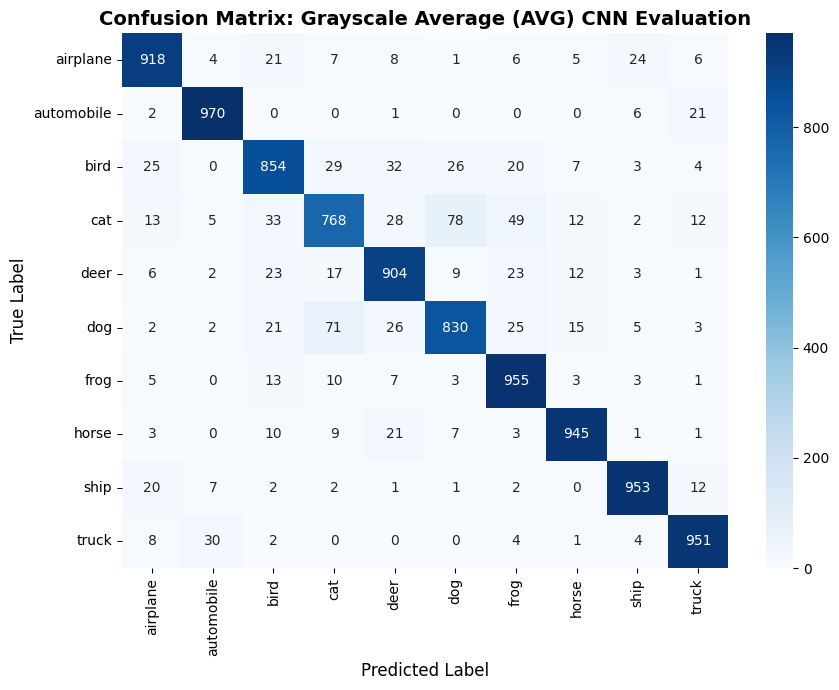

[BERHASIL] Metrik evaluasi CNN AVG berhasil disimpan dan disinkronkan.


In [3]:
cm_path = os.path.join(ARTIFACT_DIR, 'confusion_matrix_cnn.png')
metrics_cnn = evaluate_classification(
    y_true=y_test,
    y_pred=y_pred_cnn,
    title="Grayscale Average (AVG) CNN Evaluation",
    plot_cm=True,
    save_cm_path=cm_path
)

with open(os.path.join(ARTIFACT_DIR, 'metrics_cnn.json'), 'w') as f:
    json.dump(metrics_cnn, f, indent=2)

# Perbarui juga metrics.json agar selalu sinkron
metrics_json_path = os.path.join(ARTIFACT_DIR, 'metrics.json')
existing_metrics = {}
if os.path.exists(metrics_json_path):
    try:
        with open(metrics_json_path, 'r') as f:
            existing_metrics = json.load(f)
    except Exception:
        pass
existing_metrics['accuracy'] = float(metrics_cnn['accuracy'])
existing_metrics['cnn_test_accuracy'] = float(metrics_cnn['accuracy'])
if 'cnn_eval' in globals():
    existing_metrics['cnn_test_loss'] = float(cnn_eval[0])
with open(metrics_json_path, 'w') as f:
    json.dump(existing_metrics, f, indent=2)
print(f"[BERHASIL] Metrik evaluasi CNN AVG berhasil disimpan dan disinkronkan.")


---
## 🏆 3. Testing SVM Classifier & Perbandingan Komparatif (CNN vs SVM Grayscale Average)

In [4]:
import os
import sys

# Setup CUDA DLL path sebelum import TensorFlow agar cuDNN terdeteksi sempurna
_cuda_bin = r'C:\Users\daffa\anaconda3\envs\CNNgpu\Library\bin'
if os.path.exists(_cuda_bin):
    if _cuda_bin not in os.environ.get('PATH', ''):
        os.environ['PATH'] = _cuda_bin + ';' + os.environ.get('PATH', '')
    if hasattr(os, 'add_dll_directory'):
        try:
            os.add_dll_directory(_cuda_bin)
        except Exception:
            pass

import json
import h5py
import pickle
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

ARTIFACT_DIR = 'cifar10_artifacts/grayscale_avg'
final_keras_path = os.path.join(ARTIFACT_DIR, 'custom_cnn_cifar10_final.keras')

def load_injected_final_model(artifact_path):
    if not os.path.exists(artifact_path):
        raise FileNotFoundError(f"File model {artifact_path} tidak ditemukan!")
    cnn_model = tf.keras.models.load_model(artifact_path)
    with h5py.File(artifact_path, 'r') as h5f:
        if 'scaler_pickle' in h5f and 'svm_model_pickle' in h5f:
            scaler_bytes = bytes(h5f['scaler_pickle'][()])
            svm_bytes = bytes(h5f['svm_model_pickle'][()])
            scaler = pickle.loads(scaler_bytes)
            svm_model = pickle.loads(svm_bytes)
        elif 'svm_pipeline_pickle' in h5f:
            pipe_bytes = bytes(h5f['svm_pipeline_pickle'][()])
            pipe_obj = pickle.loads(pipe_bytes)
            if hasattr(pipe_obj, 'named_steps'):
                scaler = pipe_obj.named_steps.get('scaler', None)
                svm_model = pipe_obj.named_steps.get('svm', pipe_obj)
            else:
                scaler = None
                svm_model = pipe_obj
        else:
            raise KeyError(f"Dataset Scaler/SVM tidak ditemukan dalam {artifact_path}!")
        metadata = {}
        for k, v in h5f.attrs.items():
            if isinstance(v, bytes):
                metadata[k] = v.decode('utf-8')
            else:
                metadata[k] = v
    return cnn_model, scaler, svm_model, metadata


def evaluate_classification(y_true, y_pred, title='Model Evaluation', plot_cm=True, save_cm_path=None):
    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    prec_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print('=================================================================')
    print(f'  {title.upper()}')
    print('=================================================================')
    print(f'  Accuracy           : {acc * 100:.2f}% ({acc:.4f})')
    print(f'  Precision (Macro)  : {prec_macro * 100:.2f}% ({prec_macro:.4f})')
    print(f'  Recall (Macro)     : {rec_macro * 100:.2f}% ({rec_macro:.4f})')
    print(f'  F1-Score (Macro)   : {f1_macro * 100:.2f}% ({f1_macro:.4f})')
    print('-----------------------------------------------------------------')
    print(f'  Precision (Weight) : {prec_weighted * 100:.2f}% ({prec_weighted:.4f})')
    print(f'  Recall (Weight)    : {rec_weighted * 100:.2f}% ({rec_weighted:.4f})')
    print(f'  F1-Score (Weight)  : {f1_weighted * 100:.2f}% ({f1_weighted:.4f})')
    print('=================================================================')
    print('\n--- CLASSIFICATION REPORT ---')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    if plot_cm:
        plt.figure(figsize=(9, 7))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
        plt.title(f'Confusion Matrix: {title}', fontsize=14, fontweight='bold')
        plt.xlabel('Predicted Label', fontsize=12)
        plt.ylabel('True Label', fontsize=12)
        plt.tight_layout()
        if save_cm_path:
            os.makedirs(os.path.dirname(save_cm_path), exist_ok=True)
            plt.savefig(save_cm_path, dpi=200)
            print(f'[INFO] Confusion Matrix heatmap disimpan ke: {save_cm_path}')
        plt.show()

    return {
        'accuracy': float(acc),
        'precision_macro': float(prec_macro),
        'recall_macro': float(rec_macro),
        'f1_macro': float(f1_macro),
        'precision_weighted': float(prec_weighted),
        'recall_weighted': float(rec_weighted),
        'f1_weighted': float(f1_weighted),
        'confusion_matrix': cm.tolist()
    }

scaler = None
svm_model = None

# Prioritaskan pemuatan dari file standalone .pkl jika tersedia
scaler_pkl_path = os.path.join(ARTIFACT_DIR, 'scaler.pkl')
svm_pkl_path = os.path.join(ARTIFACT_DIR, 'svm_model.pkl')
if os.path.exists(scaler_pkl_path) and os.path.exists(svm_pkl_path):
    try:
        with open(scaler_pkl_path, 'rb') as f:
            scaler = pickle.load(f)
        with open(svm_pkl_path, 'rb') as f:
            svm_model = pickle.load(f)
        print(f"[BERHASIL] Scaler dan SVM Model dimuat dari file .pkl di {ARTIFACT_DIR}!")
    except Exception as e:
        print(f"[INFO] Gagal memuat dari file .pkl: {e}. Mencoba dari container .keras...")

if svm_model is None:
    print(f"Memuat model dari SATU file .keras: {final_keras_path}")
    cnn_model, scaler, svm_model, metadata = load_injected_final_model(final_keras_path)
    print(f"[BERHASIL] Scaler dan SVM Model berhasil dimuat dari file .keras!")
    print("Metadata:", metadata)


[BERHASIL] Scaler dan SVM Model dimuat dari file .pkl di cifar10_artifacts/grayscale_avg!


## 📥 1. Memuat Vektor Fitur Testing, Transformasi Scaler & Inferensi SVM


In [5]:
test_feat_path = os.path.join(ARTIFACT_DIR, 'test_features.npz')
test_data = np.load(test_feat_path)
X_test_features = test_data['X_test_features']
y_test = test_data['y_test']

print("1. Menstandarisasi vektor fitur testing menggunakan scaler training...")
if scaler is not None:
    X_test_scaled = scaler.transform(X_test_features)
else:
    X_test_scaled = X_test_features
print(f"Bentuk fitur testing terskala: {X_test_scaled.shape}")

print()
print("2. Menjalankan prediksi SVM pada seluruh test set (10.000 sampel)...")
y_pred_svm = svm_model.predict(X_test_scaled)

1. Menstandarisasi vektor fitur testing menggunakan scaler training...
Bentuk fitur testing terskala: (10000, 512)

2. Menjalankan prediksi SVM pada seluruh test set (10.000 sampel)...


## 📊 2. Classification Report & Confusion Matrix (SVM)


  GRAYSCALE AVERAGE (AVG) CNN + SVM EVALUATION
  Accuracy           : 91.78% (0.9178)
  Precision (Macro)  : 91.77% (0.9177)
  Recall (Macro)     : 91.78% (0.9178)
  F1-Score (Macro)   : 91.77% (0.9177)
-----------------------------------------------------------------
  Precision (Weight) : 91.77% (0.9177)
  Recall (Weight)    : 91.78% (0.9178)
  F1-Score (Weight)  : 91.77% (0.9177)

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

    airplane     0.9395    0.9170    0.9281      1000
  automobile     0.9537    0.9690    0.9613      1000
        bird     0.8906    0.8790    0.8848      1000
         cat     0.8335    0.8210    0.8272      1000
        deer     0.8953    0.9150    0.9050      1000
         dog     0.8620    0.8620    0.8620      1000
        frog     0.9358    0.9470    0.9414      1000
       horse     0.9606    0.9500    0.9553      1000
        ship     0.9489    0.9660    0.9574      1000
       truck     0.9568    0.9520    0.954

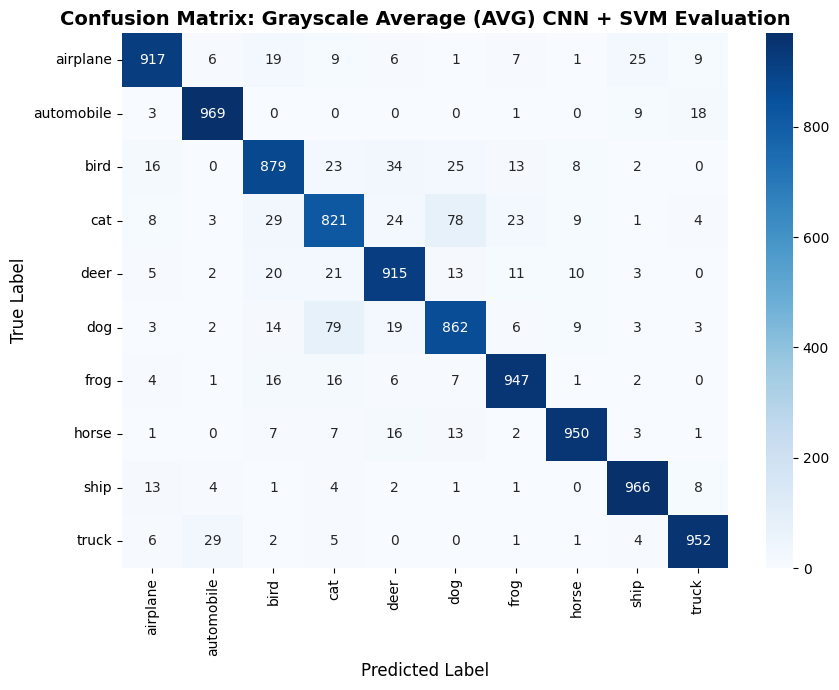


[FINAL RESULT] Grayscale Average (AVG) CNN + SVM Test Accuracy: 91.78%
[FINAL RESULT] Grayscale Average (AVG) CNN + SVM F1-Score (Macro): 91.77%


In [6]:
cm_path = os.path.join(ARTIFACT_DIR, 'confusion_matrix_svm.png')
metrics_svm = evaluate_classification(
    y_true=y_test,
    y_pred=y_pred_svm,
    title="Grayscale Average (AVG) CNN + SVM Evaluation",
    plot_cm=True,
    save_cm_path=cm_path
)

with open(os.path.join(ARTIFACT_DIR, 'metrics_svm.json'), 'w') as f:
    json.dump(metrics_svm, f, indent=2)

# Perbarui juga metrics.json agar selalu sinkron
metrics_json_path = os.path.join(ARTIFACT_DIR, 'metrics.json')
existing_metrics = {}
if os.path.exists(metrics_json_path):
    try:
        with open(metrics_json_path, 'r') as f:
            existing_metrics = json.load(f)
    except Exception:
        pass
existing_metrics['svm_test_accuracy'] = float(metrics_svm['accuracy'])
with open(metrics_json_path, 'w') as f:
    json.dump(existing_metrics, f, indent=2)

print()
print(f"[FINAL RESULT] Grayscale Average (AVG) CNN + SVM Test Accuracy: {metrics_svm['accuracy'] * 100:.2f}%")
print(f"[FINAL RESULT] Grayscale Average (AVG) CNN + SVM F1-Score (Macro): {metrics_svm['f1_macro'] * 100:.2f}%")
